# General stuff
## Import required libraries

In [1]:
!pwd

/home/ylnner/Documents/omnet++/omnetpp-6.3.0/projects/florasat_v4_ult_routing/simulations/Test_Individual/results


In [ ]:
import pickle

>>> DataFrame calculado y exportado exitosamente a 'florasat_pdr_metrics_report.csv'.
Run          5.500000
noML_PDR    32.835166
LSTM_PDR    37.419196
TRF_PDR     35.132929
dtype: float64


/tmp/ipykernel_1076197/1453403667.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[0].boxplot(box_data_pdr, labels=labels_pdr, patch_artist=True, widths=0.4)
/tmp/ipykernel_1076197/1453403667.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[1].boxplot(box_data_eff, labels=labels_eff, patch_artist=True, widths=0.5)


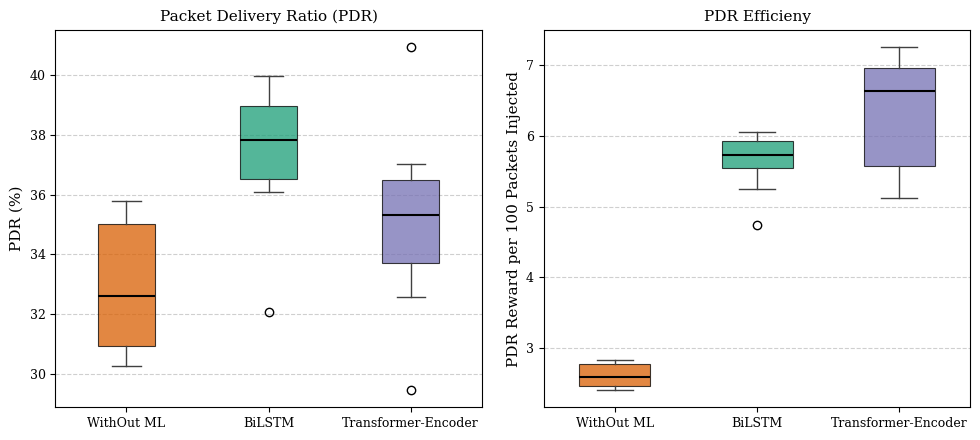

>>> Gráficos vectoriales generados: 'pdr_evolution_per_run.pdf' y 'pdr_stress_analysis_whisker.pdf'.


In [4]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================================
# 1. CONFIGURACIÓN DE ESTILOS PARA FORMATO IEEE (DOBLE COLUMNA)
# =========================================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'grid.linestyle': '--',
    'grid.alpha': 0.6
})

# Paleta de colores consistente
colors = {'noML': '#d95f02', 'LSTM': '#1b9e77', 'TRF': '#7570b3'}

# =========================================================================
# 2. FUNCIÓN PARA LEER EXTRACCIONES DIRECTAS DE FLorasat
# =========================================================================
def extract_counts_from_pkl(filename, key_name):
    """
    Lee los archivos .pkl que contienen las métricas extraídas del simulador.
    Soporta la estructura de diccionarios con escalares indexados de NumPy.
    """
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    
    # Extraer el contador de transmisiones o recepciones
    counts = []
    # Dependiendo de cómo se guardó, iteramos sobre los elementos o ejecuciones
    if isinstance(data, list):
        for run_data in data:
            if key_name in run_data:
                counts.append(float(run_data[key_name]))
    elif isinstance(data, dict):
        # Si es un único diccionario con arrays nativos de numpy
        if key_name in data:
            val = data[key_name]
            if isinstance(val, (list, np.ndarray)):
                counts = [float(x) for x in val]
            else:
                counts = [float(val)]
            
    return np.array(counts[:10]) # Asegurar exactamente los 10 Runs estructurales


df = pd.DataFrame({
    'Run': list(range(1, 11)),
    'noML_Tx': extract_counts_from_pkl('noML_run_stats_trx_at_dev.pkl', 'countTrxAtDev'),
    'noML_Ok': extract_counts_from_pkl('noML_run_stats_trx_at_sat.pkl', 'countTrxAtSat'),
    'LSTM_Tx': extract_counts_from_pkl('ML_lstm_run_stats_trx_at_dev.pkl', 'countTrxAtDev'),
    'LSTM_Ok': extract_counts_from_pkl('ML_lstm_run_stats_trx_at_sat.pkl', 'countTrxAtSat'),
    'TRF_Tx':  extract_counts_from_pkl('ML_trf_run_stats_trx_at_dev.pkl', 'countTrxAtDev'),
    'TRF_Ok':  extract_counts_from_pkl('ML_trf_run_stats_trx_at_sat.pkl', 'countTrxAtSat')
})

# =========================================================================
# 4. PROCESAMIENTO Y CÁLCULO DE MÉTRICAS ENFOCADAS EN PDR
# =========================================================================
# Packet Delivery Ratio (PDR %) estándar
df['noML_PDR'] = (df['noML_Ok'] / df['noML_Tx']) * 100
df['LSTM_PDR'] = (df['LSTM_Ok'] / df['LSTM_Tx']) * 100
df['TRF_PDR']  = (df['TRF_Ok'] / df['TRF_Tx']) * 100

# MÉTRICA DE ESTRÉS: PDR Efficiency (Rendimiento por cada unidad de carga inyectada)
# Cuánto PDR real obtenemos por cada 100 paquetes que estresan el espectro
df['noML_PDR_Efficiency'] = df['noML_PDR'] / (df['noML_Tx'] / 100)
df['LSTM_PDR_Efficiency'] = df['LSTM_PDR'] / (df['LSTM_Tx'] / 100)
df['TRF_PDR_Efficiency']  = df['TRF_PDR']  / (df['TRF_Tx'] / 100)

# MÉTRICA DE MITIGACIÓN: Ganancia Neta de PDR frente al escenario base (Puntos Porcentuales)
###df['LSTM_PDR_Gain'] = df['LSTM_PDR'] - df['noML_PDR']
###df['TRF_PDR_Gain']  = df['TRF_PDR'] - df['noML_PDR']

# Exportar métricas completas para utilizarlas en tablas de LaTeX de tu paper
df.to_csv('florasat_pdr_metrics_report.csv', index=False)
print(">>> DataFrame calculado y exportado exitosamente a 'florasat_pdr_metrics_report.csv'.")
print(df[['Run', 'noML_PDR', 'LSTM_PDR', 'TRF_PDR']].mean())


# =========================================================================
# GRÁFICO 2: DIAGRAMAS DE CAJA (WHISKER PLOTS) ENFOCADOS EN ESTRÉS DE PDR
# =========================================================================
fig2, axes = plt.subplots(1, 2, figsize=(10, 4.5))


# Agrupamos los datos de PDR calculados para el diagrama de caja
box_data_pdr = [df['noML_PDR'], df['LSTM_PDR'], df['TRF_PDR']]
labels_pdr = ['WithOut ML', 'BiLSTM', 'Transformer-Encoder']
colors_pdr = [colors['noML'], colors['LSTM'], colors['TRF']]

# Crear el Boxplot para PDR
#bp1 = ax1.boxplot(box_data_pdr, labels=labels_pdr, patch_artist=True, widths=0.45)
bp2 = axes[0].boxplot(box_data_pdr, labels=labels_pdr, patch_artist=True, widths=0.4)

# Personalización estética adaptada al formato formal de la IEEE
for patch, color in zip(bp2['boxes'], colors_pdr):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)

# Estilizar los bigotes (whiskers), topes (caps) y las líneas de la mediana
for element in ['whiskers', 'caps']:
    for line in bp2[element]:
        line.set(color='#404040', linewidth=1)
        
for median in bp2['medians']:
    median.set(color='black', linewidth=1.5)

# Títulos y configuración formal de los ejes
axes[0].set_title('Packet Delivery Ratio (PDR)')
axes[0].set_ylabel('PDR (%)')
axes[0].grid(True, axis='y')


# Subplot A: Eficiencia de Transmisión (PDR obtenido relativo al estrés provocado)
box_data_eff = [df['noML_PDR_Efficiency'], df['LSTM_PDR_Efficiency'], df['TRF_PDR_Efficiency']]
labels_eff = ['WithOut ML', 'BiLSTM', 'Transformer-Encoder']

bp1 = axes[1].boxplot(box_data_eff, labels=labels_eff, patch_artist=True, widths=0.5)
for patch, color in zip(bp1['boxes'], [colors['noML'], colors['LSTM'], colors['TRF']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)

for element in ['whiskers', 'caps']:
    for line in bp1[element]:
        line.set(color='#404040', linewidth=1)
for median in bp1['medians']:
    median.set(color='black', linewidth=1.5)

axes[1].set_title('PDR Efficieny')
axes[1].set_ylabel('PDR Reward per 100 Packets Injected')
axes[1].grid(True, axis='y')



    
plt.tight_layout()
plt.show()
plt.savefig('pdr_and_efficiency.pdf', dpi=300)

plt.close()
print(">>> Gráficos vectoriales generados: 'pdr_evolution_per_run.pdf' y 'pdr_stress_analysis_whisker.pdf'.")